<a href="https://colab.research.google.com/github/sanniakhan484-hash/kras-evolution-structure-resistance/blob/main/notebooks/01_sequence_and_blast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
from Bio import SeqIO
from io import StringIO

# UniProt accessions for the three human RAS proteins
proteins = {
    "KRAS": "P01116",
    "HRAS": "P01112",
    "NRAS": "P01111",
}

records = {}
for name, acc in proteins.items():
    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    response = requests.get(url)
    response.raise_for_status()   # stops with an error if the download failed
    record = SeqIO.read(StringIO(response.text), "fasta")
    records[name] = record
    print(f"{name} ({acc}): {len(record.seq)} amino acids")

KRAS (P01116): 189 amino acids
HRAS (P01112): 189 amino acids
NRAS (P01111): 189 amino acids


In [3]:
kras = records["KRAS"]
print(kras.description)
print()
print(str(kras.seq))
print()
print("Residue 12:", kras.seq[11], " Residue 13:", kras.seq[12], " Residue 61:", kras.seq[60])

sp|P01116|RASK_HUMAN GTPase KRas OS=Homo sapiens OX=9606 GN=KRAS PE=1 SV=1

MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQRVEDAFYTLVREIRQYRLKKISKEEKTPGCVKIKKCIIM

Residue 12: G  Residue 13: G  Residue 61: Q


In [1]:
!pip install biopython -q
import Bio
print("Biopython version:", Bio.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.0 MB/s eta 0:00:00
Biopython version: 1.88


In [6]:
from Bio.Blast import NCBIXML

with open("kras_blast_swissprot.xml") as f:
    blast_record = NCBIXML.read(f)

print("Number of hits:", len(blast_record.alignments))
print()
for aln in blast_record.alignments[:5]:
    hsp = aln.hsps[0]
    print(aln.title[:90])
    print(f"   score={hsp.score}  E-value={hsp.expect}  identities={hsp.identities}/{hsp.align_length}")

Number of hits: 100

ref|NP_001356715.1| GTPase KRas isoform a [Homo sapiens] >ref|NP_203524.1| GTPase KRas iso
   score=1003.0  E-value=3.8745e-140  identities=189/189
sp|P08644.3| RecName: Full=GTPase KRas; AltName: Full=K-Ras 2; AltName: Full=Ki-Ras; AltNa
   score=998.0  E-value=2.50294e-139  identities=187/189
sp|P01117.1| RecName: Full=GTPase KRas; AltName: Full=Ki-Ras; AltName: Full=Transforming p
   score=982.0  E-value=5.97926e-137  identities=183/189
sp|P05774.1| RecName: Full=Ras-like protein [Carassius auratus]
   score=886.0  E-value=2.1971e-122  identities=175/183
sp|P23175.1| RecName: Full=GTPase HRas; AltName: Full=Transforming protein p21/H-Ras; Flag
   score=861.0  E-value=1.71809e-118  identities=163/189


In [3]:
import re
import pandas as pd
from Bio.Blast import NCBIXML

QUERY_LEN = 189

with open("kras_blast_swissprot.xml") as f:
    blast_record = NCBIXML.read(f)

rows = []
for aln in blast_record.alignments:
    hsp = aln.hsps[0]
    first_title = aln.title.split(" >")[0]          # keep only the first merged title
    organism = re.findall(r"\[(.*?)\]", first_title)
    organism = organism[-1] if organism else "unknown"
    rows.append({
        "accession": aln.accession,
        "description": first_title[:80],
        "organism": organism,
        "score": hsp.score,
        "e_value": hsp.expect,
        "identity_pct": round(100 * hsp.identities / hsp.align_length, 1),
        "query_cover_pct": round(100 * (hsp.query_end - hsp.query_start + 1) / QUERY_LEN, 1),
        "is_viral": "virus" in first_title.lower(),
    })

df = pd.DataFrame(rows)
df.to_csv("kras_blast_hits.csv", index=False)
print(df.shape)
df.head(10)

(100, 8)


,accession,description,organism,score,e_value,identity_pct,query_cover_pct,is_viral
0,P01116,ref|NP_001356715.1| GTPase KRas isoform a [Hom...,Homo sapiens,1003.0,3.874500e-140,100.0,100.0,False
1,P08644,sp|P08644.3| RecName: Full=GTPase KRas; AltNam...,Rattus norvegicus,998.0,2.502940e-139,98.9,100.0,False
2,P01117,sp|P01117.1| RecName: Full=GTPase KRas; AltNam...,Kirsten murine sarcoma virus,982.0,5.979260e-137,96.8,100.0,True
3,P05774,sp|P05774.1| RecName: Full=Ras-like protein [C...,Carassius auratus,886.0,2.197100e-122,95.6,96.8,False
4,P23175,sp|P23175.1| RecName: Full=GTPase HRas; AltNam...,NS.C58 murine sarcoma virus,861.0,1.718090e-118,86.2,99.5,True
5,P01113,sp|P01113.1| RecName: Full=GTPase HRas; AltNam...,Moloney murine sarcoma virus,858.0,6.267920e-118,85.7,99.5,True
6,P01115,sp|P01115.1| RecName: Full=Transforming protei...,Harvey murine sarcoma virus,859.0,2.283930e-117,85.7,99.5,True
7,P01114,sp|P01114.1| RecName: Full=Transforming protei...,Rasheed rat sarcoma virus,852.0,3.465660e-116,85.2,99.5,True
8,P08642,sp|P08642.1| RecName: Full=GTPase HRas; AltNam...,Gallus gallus,826.0,4.233810e-113,88.4,99.5,False
9,P79800,sp|P79800.1| RecName: Full=GTPase KRas; AltNam...,Meleagris gallopavo,824.0,7.152480e-113,90.5,100.0,False


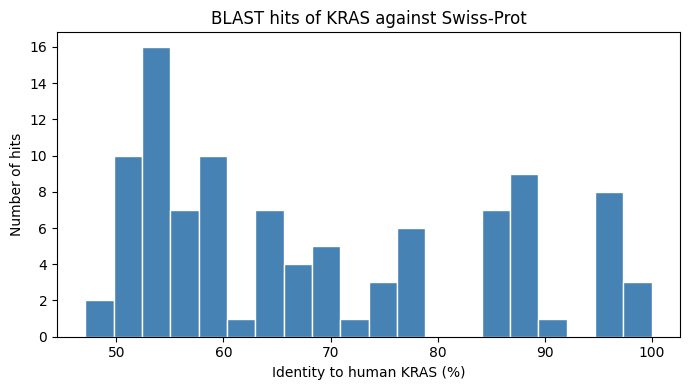

Viral entries: 5
Distinct organisms: 54


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["identity_pct"], bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Identity to human KRAS (%)")
plt.ylabel("Number of hits")
plt.title("BLAST hits of KRAS against Swiss-Prot")
plt.tight_layout()
plt.savefig("identity_histogram.png", dpi=200)
plt.show()

print("Viral entries:", df["is_viral"].sum())
print("Distinct organisms:", df["organism"].nunique())

In [5]:
print("Viral entries:", df["is_viral"].sum())
print("Distinct organisms:", df["organism"].nunique())
print()
print(df.loc[df["description"].str.contains("HRas|NRas|GTPase KRas", regex=True),
             ["accession","organism","identity_pct","query_cover_pct"]].head(15).to_string())
print()
print(df.sort_values("identity_pct").head(5)[["accession","description","organism","identity_pct"]].to_string())

Viral entries: 5
Distinct organisms: 54

   accession                      organism  identity_pct  query_cover_pct
0     P01116                  Homo sapiens         100.0            100.0
1     P08644             Rattus norvegicus          98.9            100.0
2     P01117  Kirsten murine sarcoma virus          96.8            100.0
4     P23175   NS.C58 murine sarcoma virus          86.2             99.5
5     P01113  Moloney murine sarcoma virus          85.7             99.5
8     P08642                 Gallus gallus          88.4             99.5
9     P79800           Meleagris gallopavo          90.5            100.0
10    Q91806                Xenopus laevis          88.4            100.0
11    Q5F352                 Gallus gallus          87.9            100.0
12    Q04970             Rattus norvegicus          87.4            100.0
13    P12825               Cavia porcellus          86.8            100.0
14    P01111                  Homo sapiens          86.8            100

In [6]:
import requests
from Bio import SeqIO
from io import StringIO

def fetch(acc):
    r = requests.get(f"https://rest.uniprot.org/uniprotkb/{acc}.fasta")
    r.raise_for_status()
    return SeqIO.read(StringIO(r.text), "fasta")

nonviral = df[~df["is_viral"]].drop_duplicates("accession")
subfamily = nonviral[nonviral["identity_pct"] >= 80]
print("Non-viral:", len(nonviral), " | Subfamily set (>=80%):", len(subfamily))

def build_fasta(table, outfile):
    recs, failed = [], []
    for acc, org in zip(table["accession"], table["organism"]):
        try:
            rec = fetch(acc)
            rec.id = f"{acc}_{org.replace(' ', '_')}"
            rec.description = ""
            recs.append(rec)
        except Exception as e:
            failed.append(acc)
    SeqIO.write(recs, outfile, "fasta")
    print(outfile, ":", len(recs), "sequences; failed:", failed)

build_fasta(subfamily, "ras_subfamily.fasta")
build_fasta(nonviral, "ras_superfamily.fasta")

Non-viral: 95  | Subfamily set (>=80%): 23
ras_subfamily.fasta : 23 sequences; failed: []
ras_superfamily.fasta : 95 sequences; failed: []


In [12]:
!rm -f "ras_subfamily (1).fasta" "ras_superfamily (1).fasta"
!grep -c ">" ras_subfamily.fasta ras_superfamily.fasta

ras_subfamily.fasta:23
ras_superfamily.fasta:95


In [14]:
!which mafft
!mafft --version

/usr/bin/mafft
v7.505 (2022/Apr/10)


In [15]:
import subprocess

def run_mafft(infile, outfile):
    result = subprocess.run(["mafft", "--auto", infile], capture_output=True, text=True)
    if result.returncode != 0:
        print("MAFFT failed on", infile)
        print("STDERR:", result.stderr[:2000])
        raise RuntimeError("MAFFT failed")
    with open(outfile, "w") as out:
        out.write(result.stdout)
    print(f"Aligned {infile} -> {outfile}")

run_mafft("ras_subfamily.fasta", "ras_subfamily_aligned.fasta")
run_mafft("ras_superfamily.fasta", "ras_superfamily_aligned.fasta")

Aligned ras_subfamily.fasta -> ras_subfamily_aligned.fasta
Aligned ras_superfamily.fasta -> ras_superfamily_aligned.fasta


In [16]:
from Bio import AlignIO

aln_sub = AlignIO.read("ras_subfamily_aligned.fasta", "fasta")
aln_super = AlignIO.read("ras_superfamily_aligned.fasta", "fasta")

print("Subfamily alignment:", len(aln_sub), "sequences x", aln_sub.get_alignment_length(), "columns")
print("Superfamily alignment:", len(aln_super), "sequences x", aln_super.get_alignment_length(), "columns")

Subfamily alignment: 23 sequences x 189 columns
Superfamily alignment: 95 sequences x 396 columns


In [17]:
import numpy as np
from collections import Counter
import math

def shannon_entropy(column):
    column = [c for c in column if c != "-"]
    if not column:
        return None
    counts = Counter(column)
    total = len(column)
    entropy = -sum((n/total) * math.log2(n/total) for n in counts.values())
    return entropy

def score_alignment(aln):
    n_cols = aln.get_alignment_length()
    scores = []
    for i in range(n_cols):
        col = aln[:, i]
        scores.append(shannon_entropy(col))
    return scores

entropy_sub = score_alignment(aln_sub)
entropy_super = score_alignment(aln_super)
print("Computed entropy for", len(entropy_sub), "and", len(entropy_super), "columns")

Computed entropy for 189 and 396 columns


In [18]:
import pandas as pd

def map_to_kras(aln, entropy_scores, kras_label_contains="P01116"):
    kras_row = None
    for rec in aln:
        if kras_label_contains in rec.id:
            kras_row = rec
            break
    if kras_row is None:
        raise ValueError("KRAS sequence not found in this alignment")

    rows = []
    kras_pos = 0
    for col_idx, residue in enumerate(str(kras_row.seq)):
        if residue != "-":
            kras_pos += 1
            rows.append({
                "kras_position": kras_pos,
                "kras_residue": residue,
                "alignment_column": col_idx,
                "entropy": entropy_scores[col_idx],
            })
    return pd.DataFrame(rows)

cons_sub = map_to_kras(aln_sub, entropy_sub)
cons_super = map_to_kras(aln_super, entropy_super)

print(cons_sub[cons_sub["kras_position"].isin([12, 13, 61])])
print()
print("Subfamily table:", cons_sub.shape, " | Superfamily table:", cons_super.shape)

cons_sub.to_csv("conservation_subfamily.csv", index=False)
cons_super.to_csv("conservation_superfamily.csv", index=False)

    kras_position kras_residue  alignment_column   entropy
11             12            G                11  0.258019
12             13            G                12 -0.000000
60             61            Q                60 -0.000000

Subfamily table: (189, 4)  | Superfamily table: (189, 4)


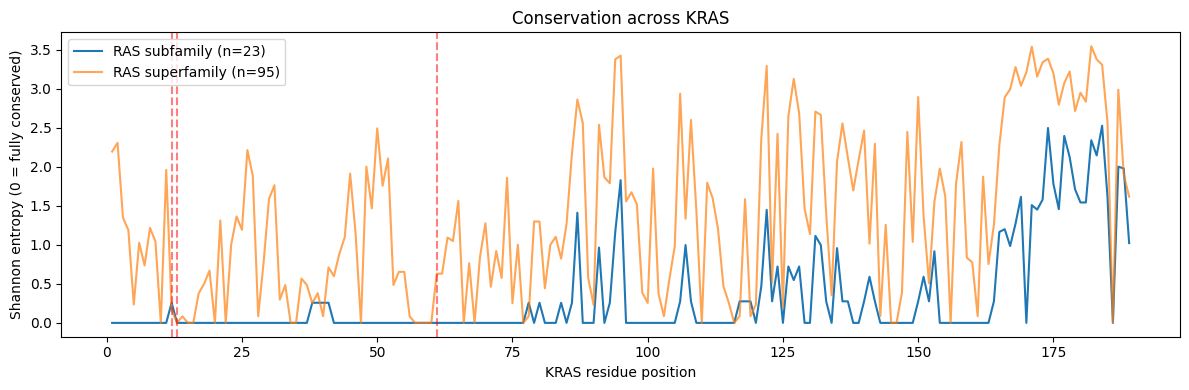

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(cons_sub["kras_position"], cons_sub["entropy"], label="RAS subfamily (n=23)")
plt.plot(cons_super["kras_position"], cons_super["entropy"], label="RAS superfamily (n=95)", alpha=0.7)
plt.axvline(12, color="red", linestyle="--", alpha=0.5)
plt.axvline(13, color="red", linestyle="--", alpha=0.5)
plt.axvline(61, color="red", linestyle="--", alpha=0.5)
plt.xlabel("KRAS residue position")
plt.ylabel("Shannon entropy (0 = fully conserved)")
plt.title("Conservation across KRAS")
plt.legend()
plt.tight_layout()
plt.savefig("conservation_plot.png", dpi=200)
plt.show()

In [20]:
# Known KRAS functional motifs (standard annotation, canonical numbering)
motifs = {
    "P-loop / G1 (GTP binding)": (10, 17),
    "Switch I / G2": (30, 40),
    "Switch II / G3": (57, 64),
    "G4 motif (guanine specificity)": (116, 119),
    "G5 motif": (145, 148),
    "Hypervariable region (HVR)": (166, 185),
}

for name, (start, end) in motifs.items():
    seg = cons_sub[(cons_sub["kras_position"] >= start) & (cons_sub["kras_position"] <= end)]
    print(f"{name:35s} mean entropy = {seg['entropy'].mean():.3f}")

P-loop / G1 (GTP binding)           mean entropy = 0.032
Switch I / G2                       mean entropy = 0.070
Switch II / G3                      mean entropy = 0.000
G4 motif (guanine specificity)      mean entropy = 0.207
G5 motif                            mean entropy = 0.000
Hypervariable region (HVR)          mean entropy = 1.665


In [22]:
import requests

def download(url, outfile):
    r = requests.get(url)
    r.raise_for_status()
    with open(outfile, "wb") as f:
        f.write(r.content)
    print(f"Saved {outfile} ({len(r.content)} bytes)")

# Query the AlphaFold API for the current file URLs for KRAS (P01116)
api_resp = requests.get("https://alphafold.ebi.ac.uk/api/prediction/P01116")
api_resp.raise_for_status()
af_info = api_resp.json()[0]   # first (and usually only) model
print("AlphaFold model version:", af_info.get("latestVersion"))
print("PDB URL:", af_info["pdbUrl"])

download(af_info["pdbUrl"], "kras_alphafold.pdb")

# PDB structures are unaffected by this change
download("https://files.rcsb.org/download/4OBE.pdb", "kras_gdp_4OBE.pdb")
download("https://files.rcsb.org/download/6OIM.pdb", "kras_sotorasib_6OIM.pdb")

AlphaFold model version: 6
PDB URL: https://alphafold.ebi.ac.uk/files/AF-P01116-F1-model_v6.pdb
Saved kras_alphafold.pdb (127979 bytes)
Saved kras_gdp_4OBE.pdb (750465 bytes)
Saved kras_sotorasib_6OIM.pdb (173016 bytes)


In [23]:
from Bio.PDB import PDBParser, PDBIO
import pandas as pd

cons = pd.read_csv("conservation_subfamily.csv")
entropy_by_pos = dict(zip(cons["kras_position"], cons["entropy"]))

def write_conservation_bfactor(infile, outfile, entropy_map, chain_id=None):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("kras", infile)
    n_set, n_missing = 0, 0
    for model in structure:
        for chain in model:
            if chain_id and chain.id != chain_id:
                continue
            for residue in chain:
                resnum = residue.id[1]
                if resnum in entropy_map:
                    val = entropy_map[resnum]
                    n_set += 1
                else:
                    val = 0.0
                    n_missing += 1
                for atom in residue:
                    atom.set_bfactor(val)
    io = PDBIO()
    io.set_structure(structure)
    io.save(outfile)
    print(f"{outfile}: set {n_set} residues, {n_missing} had no conservation score")

write_conservation_bfactor("kras_alphafold.pdb", "kras_alphafold_conservation.pdb", entropy_by_pos)
write_conservation_bfactor("kras_gdp_4OBE.pdb", "kras_gdp_4OBE_conservation.pdb", entropy_by_pos, chain_id="A")
write_conservation_bfactor("kras_sotorasib_6OIM.pdb", "kras_sotorasib_6OIM_conservation.pdb", entropy_by_pos, chain_id="A")

kras_alphafold_conservation.pdb: set 189 residues, 0 had no conservation score
kras_gdp_4OBE_conservation.pdb: set 169 residues, 178 had no conservation score
kras_sotorasib_6OIM_conservation.pdb: set 166 residues, 211 had no conservation score


In [24]:
import py3Dmol

def show_structure(pdb_file, colorscale_max=2.0):
    with open(pdb_file) as f:
        pdb_data = f.read()
    view = py3Dmol.view(width=700, height=500)
    view.addModel(pdb_data, "pdb")
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 0, "max": colorscale_max}}})
    view.zoomTo()
    return view

show_structure("kras_alphafold_conservation.pdb")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
import requests
import pandas as pd

BASE = "https://www.cbioportal.org/api"

gene_resp = requests.get(f"{BASE}/genes/KRAS")
gene_resp.raise_for_status()
gene_info = gene_resp.json()
print(gene_info)
entrez_id = gene_info["entrezGeneId"]

{'entrezGeneId': 3845, 'hugoGeneSymbol': 'KRAS', 'type': 'protein-coding'}


In [2]:
# Get the list of available studies, filter for a large pan-cancer one
studies_resp = requests.get(f"{BASE}/studies?pageSize=500")
studies_resp.raise_for_status()
studies = studies_resp.json()

# Look for MSK-IMPACT or TCGA pan-cancer studies (large, well-curated)
pancan_candidates = [s for s in studies if "pancan" in s["studyId"].lower() or "msk_impact" in s["studyId"].lower()]
for s in pancan_candidates[:10]:
    print(s["studyId"], "-", s["name"])

braf_msk_impact_2024 - BRAF Fusions - IMPACT Clinical Sequencing Cohort (MSK, Clin Cancer Res 2024)
heme_msk_impact_2022 - MSK-IMPACT Heme Tumors (MSK, 2022)
pancan_mappyacts_2022 - Pediatric European MAPPYACTS Trial (Gustave Roussy, Cancer Discov 2022)
pancan_mimsi_msk_2024 - Mixed Tumors - MiMSI Cohort (MSK, Nat Commun 2024)
pancan_pdx_uthsa_2023 - Pediatric solid tumor PDXs (UTHSA, Nat Commun 2023)
pancan_pdmr_2025 - NCI Patient-Derived Models Repository (PDMR, 2025)
pancan_ped_mai_msk_2025 - Pediatric Tumors (MSK, 2025)
pancan_pcawg_2020 - Pan-cancer analysis of whole genomes (ICGC/TCGA, Nature 2020)
pancan_hcmi_2025 - Pan-cancer Analysis of Organoid Samples (HCMI, 2025)


In [3]:
STUDY_ID = "pancan_pcawg_2020"

# Find the mutation profile ID for this study
profiles_resp = requests.get(f"{BASE}/studies/{STUDY_ID}/molecular-profiles")
profiles_resp.raise_for_status()
profiles = profiles_resp.json()

for p in profiles:
    print(p["molecularProfileId"], "-", p["molecularAlterationType"])

pancan_pcawg_2020_cna - COPY_NUMBER_ALTERATION
pancan_pcawg_2020_mirna - MRNA_EXPRESSION
pancan_pcawg_2020_mirna_median_Zscores - MRNA_EXPRESSION
pancan_pcawg_2020_mrna_seq_fpkm_capture - MRNA_EXPRESSION
pancan_pcawg_2020_mrna_seq_fpkm_capture_all_sample_Zscores - MRNA_EXPRESSION
pancan_pcawg_2020_mutational_signatures_contribution_DBS - GENERIC_ASSAY
pancan_pcawg_2020_mutational_signatures_contribution_ID - GENERIC_ASSAY
pancan_pcawg_2020_mutational_signatures_contribution_SBS - GENERIC_ASSAY
pancan_pcawg_2020_mutational_signatures_counts_DBS - GENERIC_ASSAY
pancan_pcawg_2020_mutational_signatures_counts_ID - GENERIC_ASSAY
pancan_pcawg_2020_mutational_signatures_counts_SBS - GENERIC_ASSAY
pancan_pcawg_2020_mutations - MUTATION_EXTENDED


In [4]:
MOL_PROFILE_ID = "pancan_pcawg_2020_mutations"

# We also need the sample list ID for "all samples" in this study
samples_resp = requests.get(f"{BASE}/studies/{STUDY_ID}/sample-lists")
samples_resp.raise_for_status()
sample_lists = samples_resp.json()
for sl in sample_lists:
    print(sl["sampleListId"], "-", sl["name"])

pancan_pcawg_2020_all - All samples
pancan_pcawg_2020_cna - Samples with CNA data
pancan_pcawg_2020_cnaseq - Samples with mutation and CNA data
pancan_pcawg_2020_microrna - Samples with microRNA data (microRNA-Seq)
pancan_pcawg_2020_sequenced - Samples with mutation data


In [5]:
SAMPLE_LIST_ID = "pancan_pcawg_2020_sequenced"

mutations_resp = requests.post(
    f"{BASE}/molecular-profiles/{MOL_PROFILE_ID}/mutations/fetch",
    params={"projection": "DETAILED"},
    json={
        "entrezGeneIds": [entrez_id],
        "sampleListId": SAMPLE_LIST_ID,
    },
)
mutations_resp.raise_for_status()
mutations = mutations_resp.json()

print("Total KRAS mutation records:", len(mutations))
print()
print(mutations[0] if mutations else "No mutations found")

Total KRAS mutation records: 278

{'uniqueSampleKey': 'U1AxMDIxMTM6cGFuY2FuX3BjYXdnXzIwMjA', 'uniquePatientKey': 'RE80NjU4NjpwYW5jYW5fcGNhd2dfMjAyMA', 'molecularProfileId': 'pancan_pcawg_2020_mutations', 'sampleId': 'SP102113', 'patientId': 'DO46586', 'entrezGeneId': 3845, 'gene': {'entrezGeneId': 3845, 'hugoGeneSymbol': 'KRAS', 'type': 'protein-coding'}, 'studyId': 'pancan_pcawg_2020', 'center': 'NA', 'mutationStatus': 'NA', 'validationStatus': 'NA', 'tumorAltCount': 24, 'tumorRefCount': 33, 'chr': '12', 'startPosition': 25398284, 'endPosition': 25398284, 'referenceAllele': 'C', 'variantAllele': 'A', 'proteinChange': 'G12V', 'mutationType': 'Missense_Mutation', 'ncbiBuild': 'GRCh37', 'variantType': 'SNP', 'refseqMrnaId': 'NM_033360.2', 'proteinPosStart': 12, 'proteinPosEnd': 12, 'keyword': 'KRAS G12 missense'}


In [6]:
rows = []
for m in mutations:
    rows.append({
        "sample_id": m["sampleId"],
        "patient_id": m["patientId"],
        "protein_change": m.get("proteinChange"),
        "position": m.get("proteinPosStart"),
        "mutation_type": m.get("mutationType"),
        "chromosome": m.get("chr"),
    })

mut_df = pd.DataFrame(rows)

# Keep only missense mutations (the ones relevant to our conservation/structure analysis)
mut_df_missense = mut_df[mut_df["mutation_type"] == "Missense_Mutation"].copy()

print("Total records:", len(mut_df))
print("Missense mutations:", len(mut_df_missense))
print()
print("Top 15 most frequently mutated positions:")
print(mut_df_missense["position"].value_counts().head(15))

mut_df.to_csv("kras_cbioportal_mutations_raw.csv", index=False)
mut_df_missense.to_csv("kras_cbioportal_mutations_missense.csv", index=False)

Total records: 278
Missense mutations: 278

Top 15 most frequently mutated positions:
position
12     227
61      19
13      11
117      6
146      5
19       2
22       2
68       1
62       1
118      1
60       1
73       1
63       1
Name: count, dtype: int64


In [8]:
from google.colab import files
uploaded = files.upload()   # choose conservation_subfamily.csv from your computer

Saving conservation_subfamily.csv to conservation_subfamily.csv


In [9]:
import pandas as pd
cons_sub = pd.read_csv("conservation_subfamily.csv")
print(cons_sub.shape)
cons_sub.head()

(189, 4)


,kras_position,kras_residue,alignment_column,entropy
0,1,M,0,-0.0
1,2,T,1,-0.0
2,3,E,2,-0.0
3,4,Y,3,-0.0
4,5,K,4,-0.0


In [10]:
# Count mutations per position
mut_counts = mut_df_missense["position"].value_counts().reset_index()
mut_counts.columns = ["kras_position", "mutation_count"]

# Merge with conservation (left join so every KRAS residue is kept, even with 0 mutations)
merged = cons_sub.merge(mut_counts, on="kras_position", how="left")
merged["mutation_count"] = merged["mutation_count"].fillna(0).astype(int)

print(merged.shape)
print()
print("Residues with at least one mutation:", (merged["mutation_count"] > 0).sum())
print()
merged[merged["mutation_count"] > 0].sort_values("mutation_count", ascending=False)

(189, 5)

Residues with at least one mutation: 13



,kras_position,kras_residue,alignment_column,entropy,mutation_count
11,12,G,11,0.258019,227
60,61,Q,60,-0.000000,19
12,13,G,12,-0.000000,11
116,117,K,116,0.276195,6
145,146,A,145,-0.000000,5
18,19,L,18,-0.000000,2
21,22,Q,21,-0.000000,2
59,60,G,59,-0.000000,1
61,62,E,61,-0.000000,1
67,68,R,67,-0.000000,1


Mean entropy at mutated positions:    0.0623
Mean entropy at non-mutated positions: 0.3483
Mann-Whitney U test: statistic=954.5, p-value=0.2387


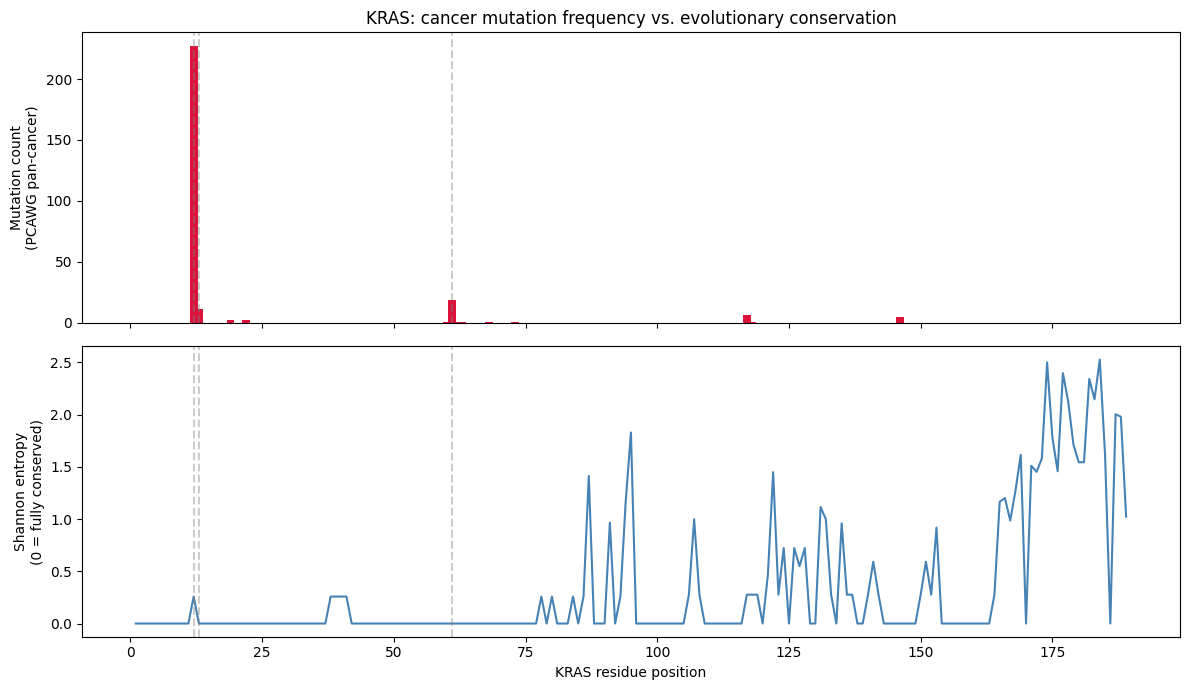

In [11]:
import matplotlib.pyplot as plt
from scipy import stats

# Compare entropy of mutated vs non-mutated positions
mutated = merged[merged["mutation_count"] > 0]["entropy"]
non_mutated = merged[merged["mutation_count"] == 0]["entropy"]

print("Mean entropy at mutated positions:   ", round(mutated.mean(), 4))
print("Mean entropy at non-mutated positions:", round(non_mutated.mean(), 4))

# Mann-Whitney U test (non-parametric, robust to the small n and skewed distribution here)
stat, pval = stats.mannwhitneyu(mutated, non_mutated, alternative="two-sided")
print(f"Mann-Whitney U test: statistic={stat:.1f}, p-value={pval:.4f}")

# Plot: mutation frequency vs conservation, side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(merged["kras_position"], merged["mutation_count"], color="crimson", width=1.5)
axes[0].set_ylabel("Mutation count\n(PCAWG pan-cancer)")
axes[0].set_title("KRAS: cancer mutation frequency vs. evolutionary conservation")

axes[1].plot(merged["kras_position"], merged["entropy"], color="steelblue")
axes[1].set_ylabel("Shannon entropy\n(0 = fully conserved)")
axes[1].set_xlabel("KRAS residue position")

for ax in axes:
    for pos in [12, 13, 61]:
        ax.axvline(pos, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mutation_vs_conservation.png", dpi=200)
plt.show()